# **Heart Attack Prediction Model**

---



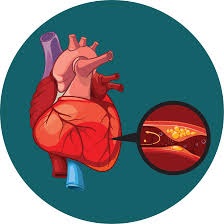  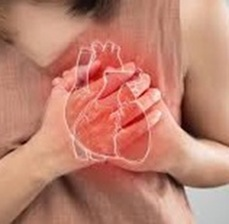

# Project Objective:

To predict the chances of heart attack among heart patients.

---



## Importing Libraries

In [248]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Importing the dataset

In [249]:
df = pd.read_csv('heart.csv')
df.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
720,48,M,ASY,124,274,0,LVH,166,N,0.5,Flat,1
353,58,M,ASY,130,0,0,ST,100,Y,1.0,Flat,1
496,58,M,ASY,132,458,1,Normal,69,N,1.0,Down,0
284,42,M,ASY,140,358,0,Normal,170,N,0.0,Up,0
753,34,F,ATA,118,210,0,Normal,192,N,0.7,Up,0
212,56,M,NAP,130,276,0,Normal,128,Y,1.0,Up,0
334,51,M,ASY,130,0,1,Normal,170,N,-0.7,Up,1
429,63,M,NAP,133,0,0,LVH,120,Y,1.0,Flat,1
740,54,F,NAP,160,201,0,Normal,163,N,0.0,Up,0
644,71,F,NAP,110,265,1,LVH,130,N,0.0,Up,0


**Types of chest pain:**

1.	ASY - Asymptomatic: The person does not feel chest pain.

2.	NAP – Non Anginal Pain: Chest pain not related to heart.

3.	ATA – Atypical Angina: Chest discomfort that is similar to angina but does not meet all the criteria.

4.	TA – Typical Angina : Angina associated with coronary artery disease.


Angina is a heart discomfort that occurs when heart muscles does not receives enough oxygen rich blood


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


There are no missing values in our dataset.

# Exploratory Data Analysis

### Univariate Analysis:

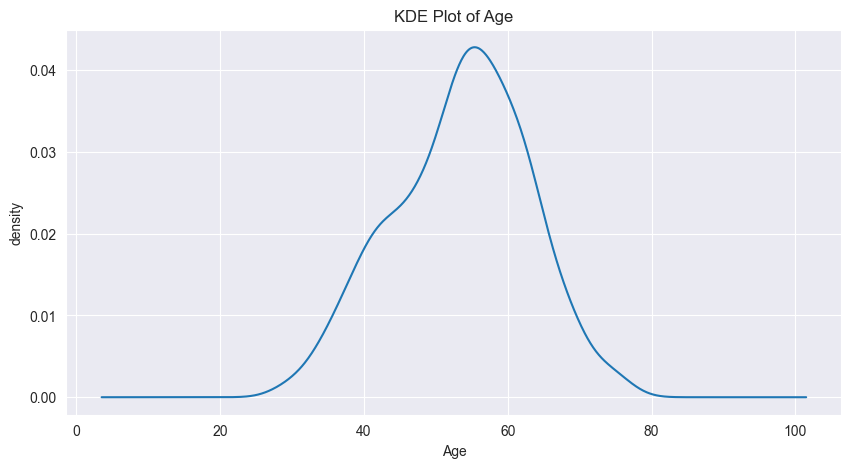

In [251]:
plt.figure(figsize=(10,5))
df['Age'].plot(kind='kde')
plt.title("KDE Plot of Age")
plt.xlabel("Age")
plt.ylabel("density")
plt.show()
plt.show()

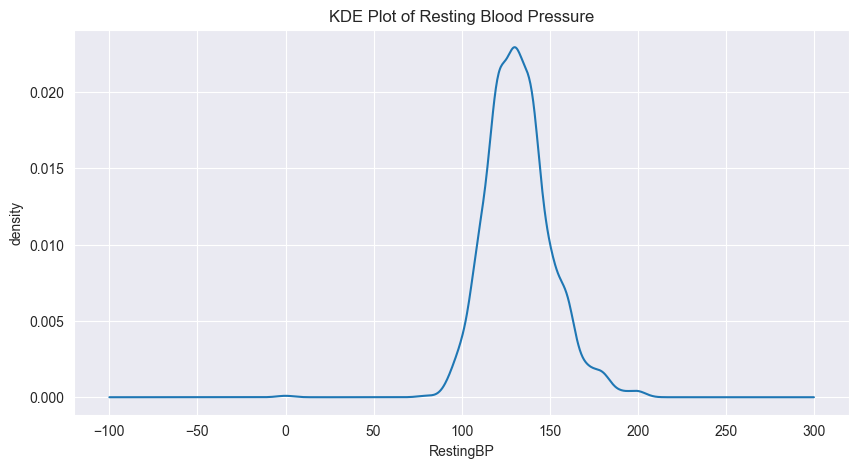

In [252]:
plt.figure(figsize=(10,5))
df['RestingBP'].plot(kind='kde')
plt.title("KDE Plot of Resting Blood Pressure")
plt.xlabel("RestingBP")
plt.ylabel("density")
plt.show()
plt.show()

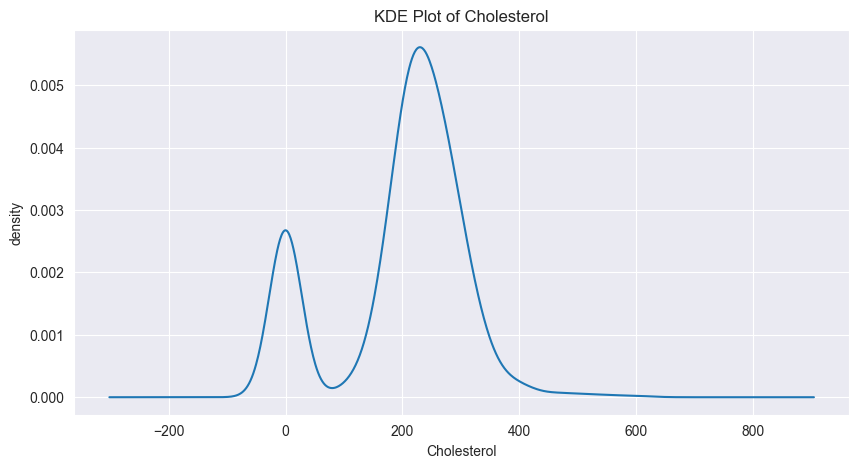

In [253]:
plt.figure(figsize=(10,5))
df['Cholesterol'].plot(kind='kde')
plt.title("KDE Plot of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("density")
plt.show()
plt.show()

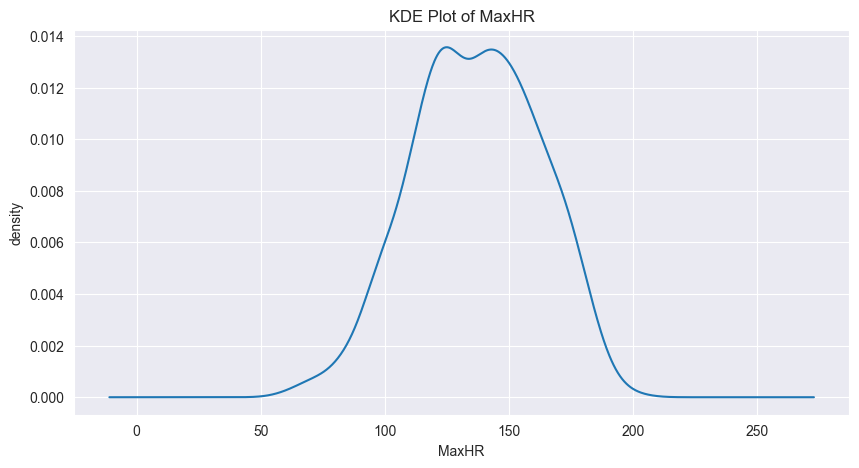

In [254]:
plt.figure(figsize=(10,5),)
df['MaxHR'].plot(kind='kde')
plt.title("KDE Plot of MaxHR")
plt.xlabel("MaxHR")
plt.ylabel("density")
plt.show()
plt.show()

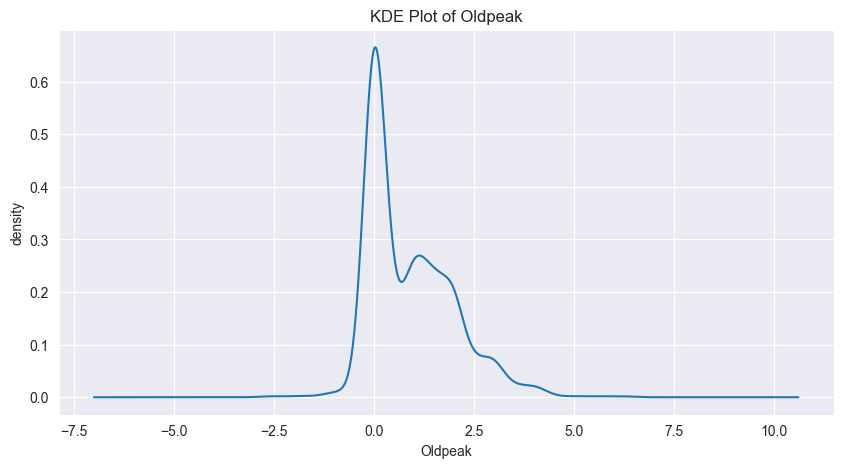

In [255]:
plt.figure(figsize=(10,5),)
df['Oldpeak'].plot(kind='kde')
plt.title("KDE Plot of Oldpeak")
plt.xlabel("Oldpeak")
plt.ylabel("density")
plt.show()
plt.show()

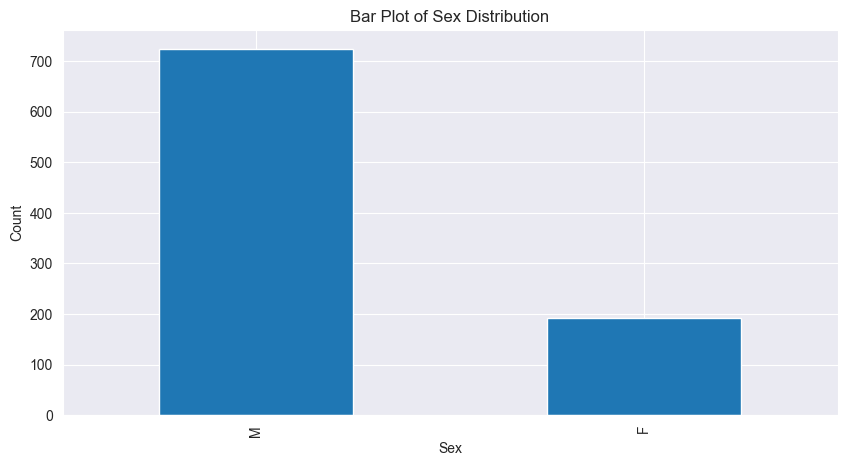

In [256]:
plt.figure(figsize=(10,5))
df['Sex'].value_counts().plot(kind='bar')
plt.title("Bar Plot of Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

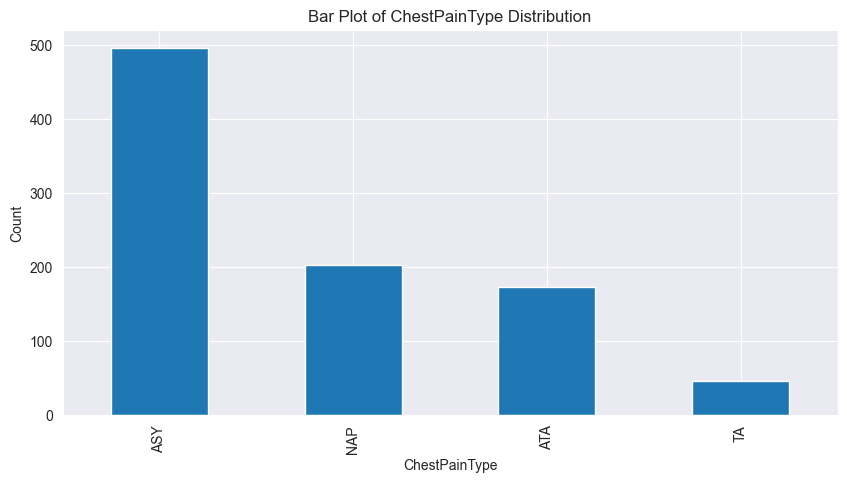

In [257]:
plt.figure(figsize=(10,5))
df['ChestPainType'].value_counts().plot(kind='bar')
plt.title("Bar Plot of ChestPainType Distribution")
plt.xlabel("ChestPainType")
plt.ylabel("Count")
plt.show()
plt.show()

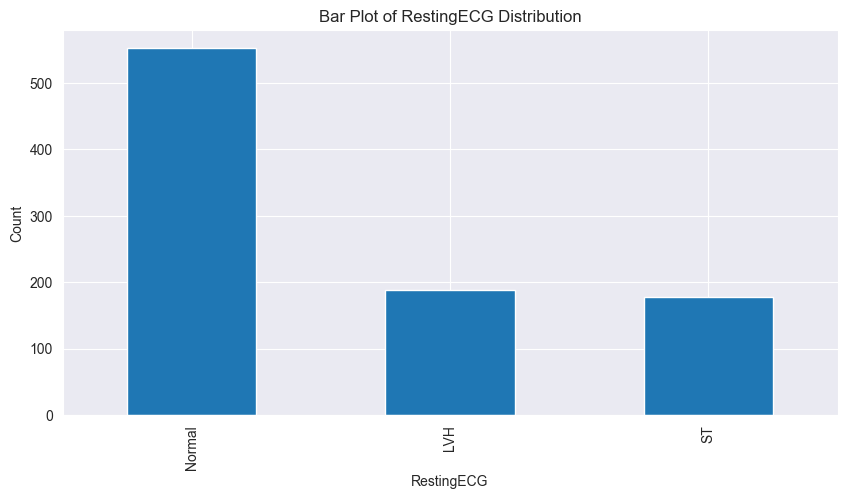

In [258]:
plt.figure(figsize=(10,5))
df['RestingECG'].value_counts().plot(kind='bar')
plt.title("Bar Plot of RestingECG Distribution")
plt.xlabel("RestingECG")
plt.ylabel("Count")
plt.show()

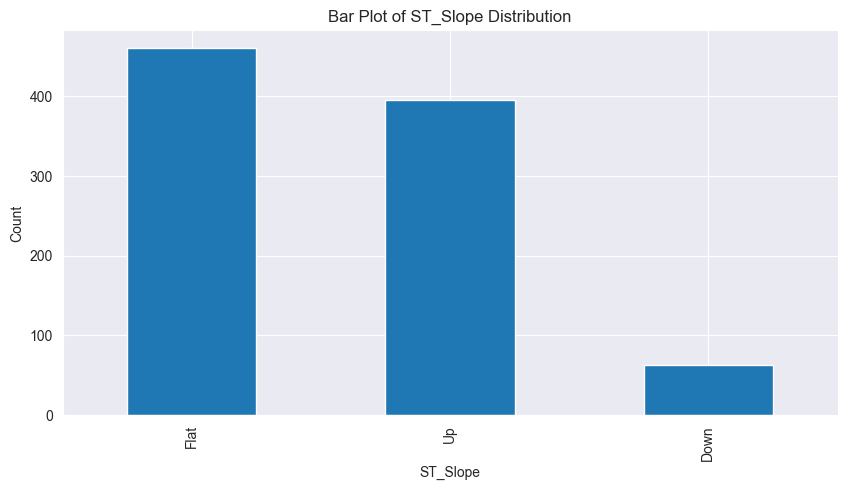

In [259]:
plt.figure(figsize=(10,5))
df['ST_Slope'].value_counts().plot(kind='bar')
plt.title("Bar Plot of ST_Slope Distribution")
plt.xlabel("ST_Slope")
plt.ylabel("Count")
plt.show()

### Bivariate Analysis:

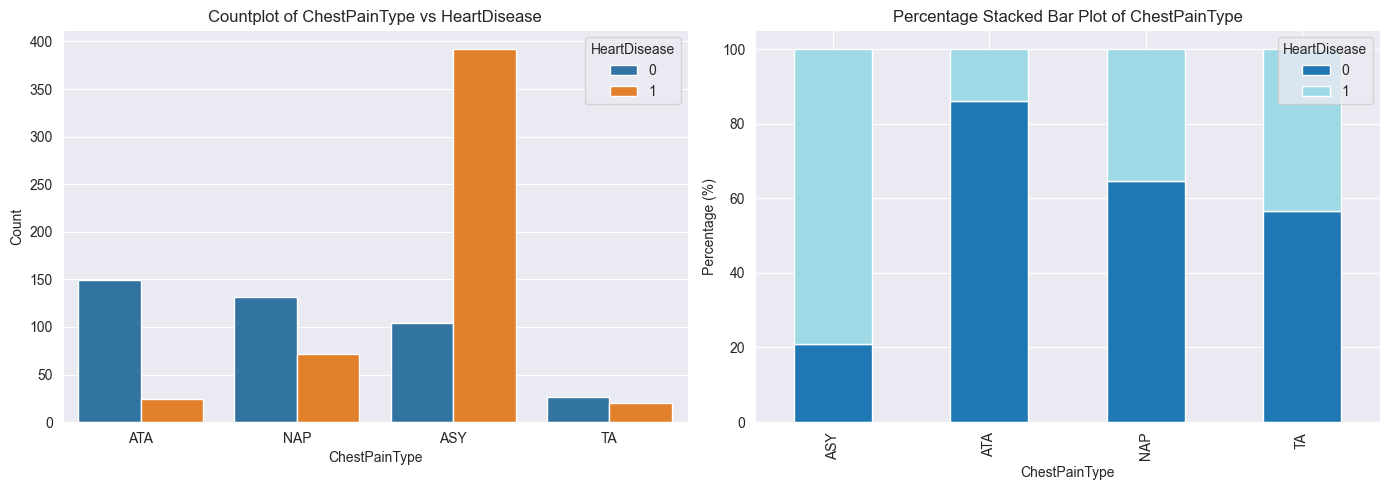

In [260]:
# ---- SETUP ----
cat_col = "ChestPainType"      # change to any categorical column
target = "HeartDisease"

# ---- COMPUTE PERCENTAGE TABLE ----
pct_df = (
    pd.crosstab(df[cat_col], df[target], normalize='index') * 100
)

# ---- PLOTTING SIDE BY SIDE ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ Countplot
sns.countplot(x=cat_col, hue=target, data=df, ax=axes[0])
axes[0].set_title(f"Countplot of {cat_col} vs {target}")
axes[0].set_xlabel(cat_col)
axes[0].set_ylabel("Count")

# 2️⃣ Percentage Stacked Bar Chart
pct_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title(f"Percentage Stacked Bar Plot of {cat_col}")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title=target)

plt.tight_layout()
plt.show()


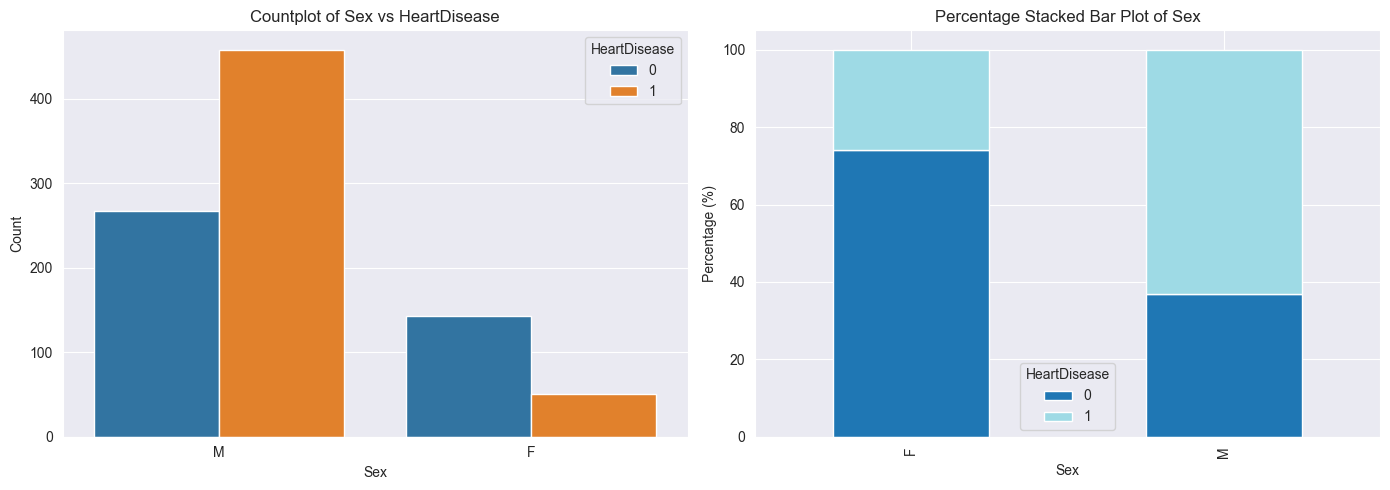

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---- SETUP ----
cat_col = "Sex"      # change to any categorical column
target = "HeartDisease"

# ---- COMPUTE PERCENTAGE TABLE ----
pct_df = (
    pd.crosstab(df[cat_col], df[target], normalize='index') * 100
)

# ---- PLOTTING SIDE BY SIDE ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ Countplot
sns.countplot(x=cat_col, hue=target, data=df, ax=axes[0])
axes[0].set_title(f"Countplot of {cat_col} vs {target}")
axes[0].set_xlabel(cat_col)
axes[0].set_ylabel("Count")

# 2️⃣ Percentage Stacked Bar Chart
pct_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title(f"Percentage Stacked Bar Plot of {cat_col}")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title=target)

plt.tight_layout()
plt.show()


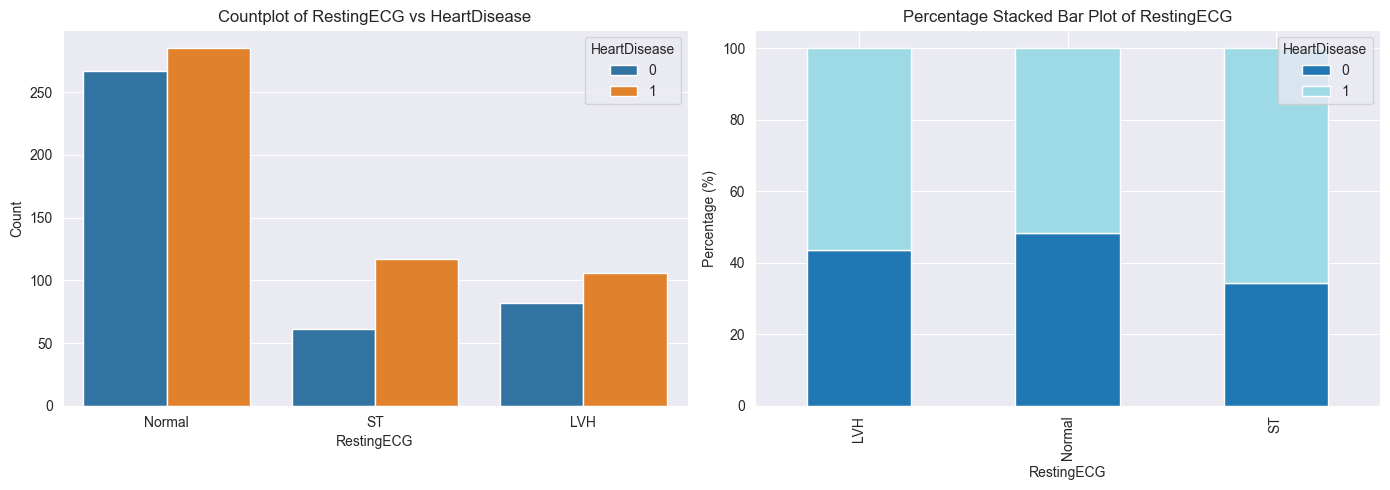

In [262]:
# ---- SETUP ----
cat_col = "RestingECG"      # change to any categorical column
target = "HeartDisease"

# ---- COMPUTE PERCENTAGE TABLE ----
pct_df = (
    pd.crosstab(df[cat_col], df[target], normalize='index') * 100
)

# ---- PLOTTING SIDE BY SIDE ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ Countplot
sns.countplot(x=cat_col, hue=target, data=df, ax=axes[0])
axes[0].set_title(f"Countplot of {cat_col} vs {target}")
axes[0].set_xlabel(cat_col)
axes[0].set_ylabel("Count")

# 2️⃣ Percentage Stacked Bar Chart
pct_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title(f"Percentage Stacked Bar Plot of {cat_col}")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title=target)

plt.tight_layout()
plt.show()


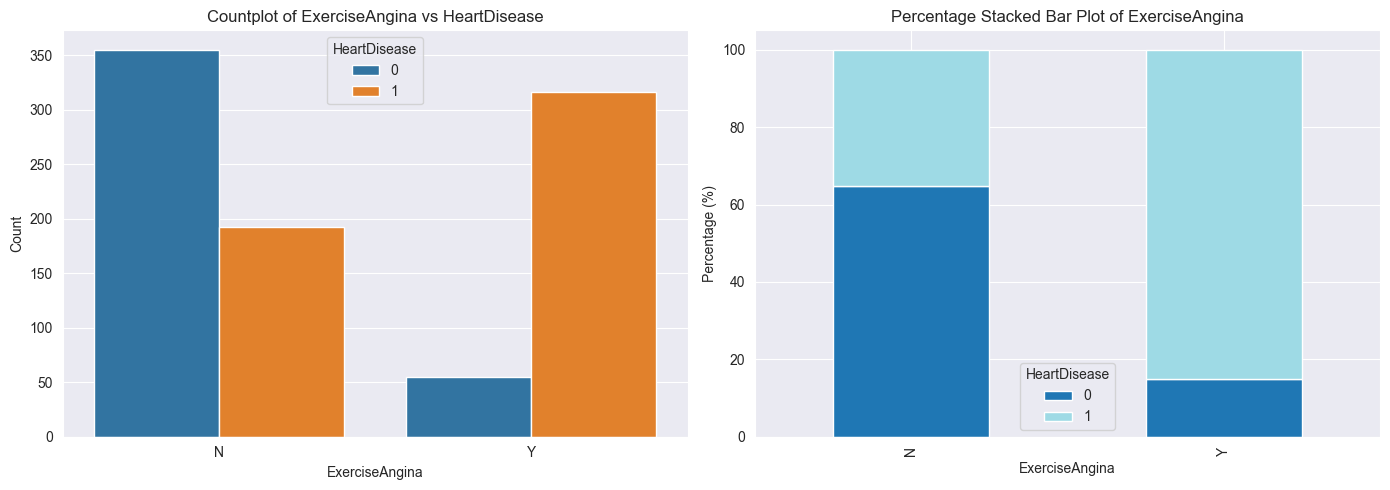

In [263]:
# ---- SETUP ----
cat_col = "ExerciseAngina"      # change to any categorical column
target = "HeartDisease"

# ---- COMPUTE PERCENTAGE TABLE ----
pct_df = (
    pd.crosstab(df[cat_col], df[target], normalize='index') * 100
)

# ---- PLOTTING SIDE BY SIDE ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ Countplot
sns.countplot(x=cat_col, hue=target, data=df, ax=axes[0])
axes[0].set_title(f"Countplot of {cat_col} vs {target}")
axes[0].set_xlabel(cat_col)
axes[0].set_ylabel("Count")

# 2️⃣ Percentage Stacked Bar Chart
pct_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title(f"Percentage Stacked Bar Plot of {cat_col}")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title=target)

plt.tight_layout()
plt.show()


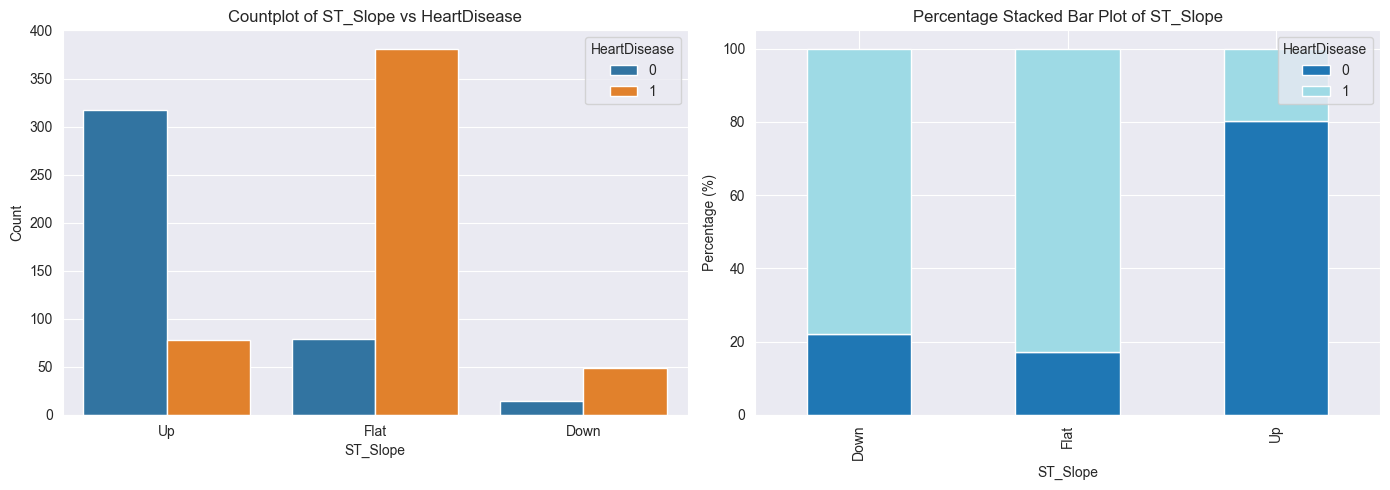

In [264]:
# ---- SETUP ----
cat_col = "ST_Slope"      # change to any categorical column
target = "HeartDisease"

# ---- COMPUTE PERCENTAGE TABLE ----
pct_df = (
    pd.crosstab(df[cat_col], df[target], normalize='index') * 100
)

# ---- PLOTTING SIDE BY SIDE ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ Countplot
sns.countplot(x=cat_col, hue=target, data=df, ax=axes[0])
axes[0].set_title(f"Countplot of {cat_col} vs {target}")
axes[0].set_xlabel(cat_col)
axes[0].set_ylabel("Count")

# 2️⃣ Percentage Stacked Bar Chart
pct_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title(f"Percentage Stacked Bar Plot of {cat_col}")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title=target)

plt.tight_layout()
plt.show()


Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


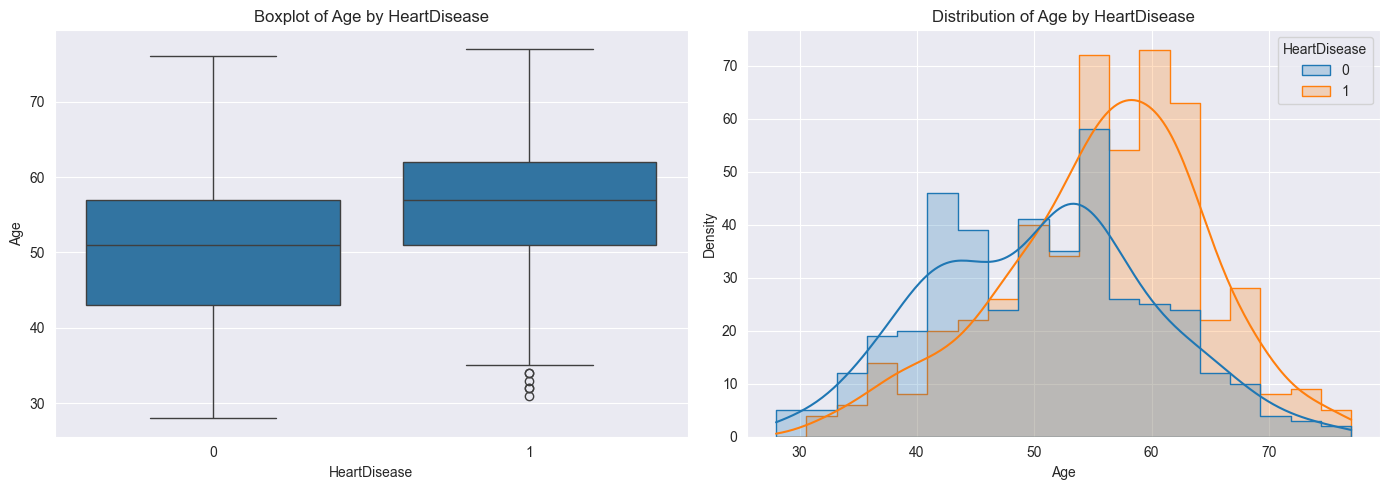

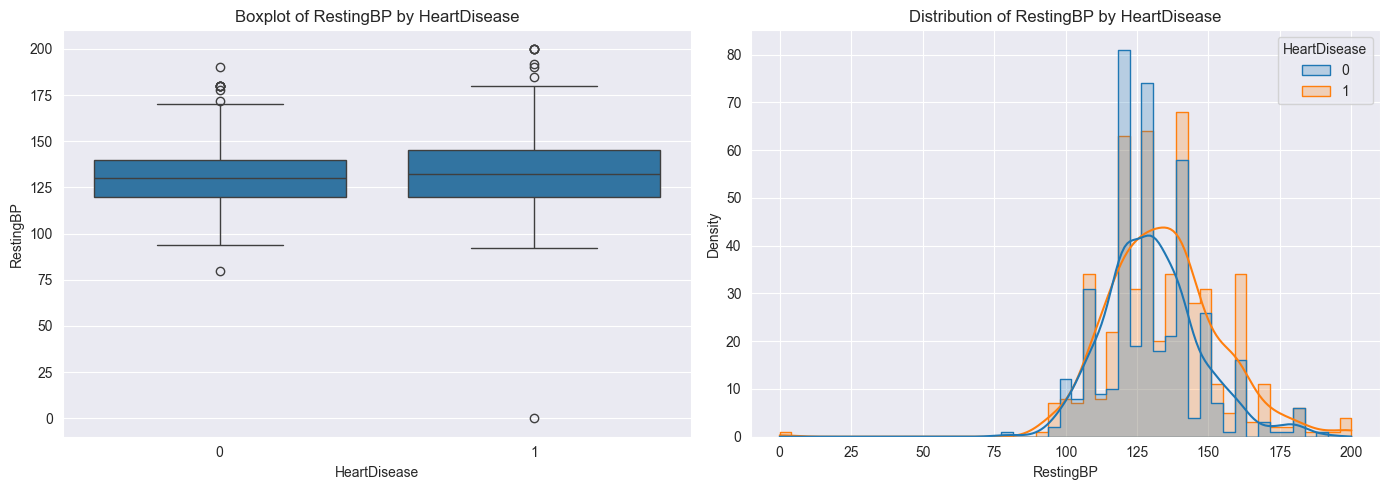

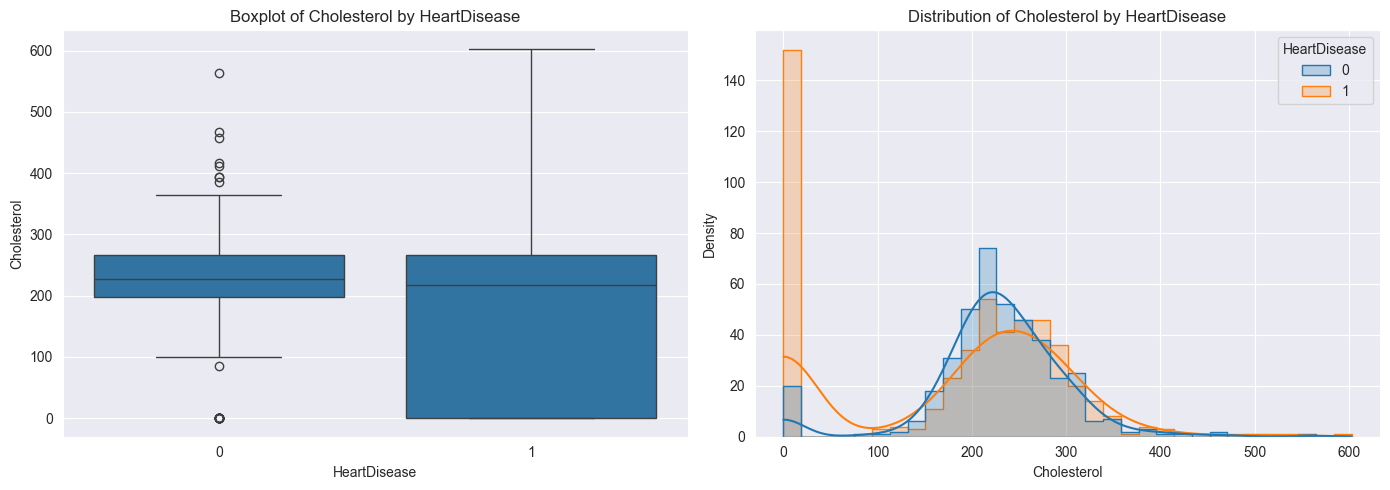

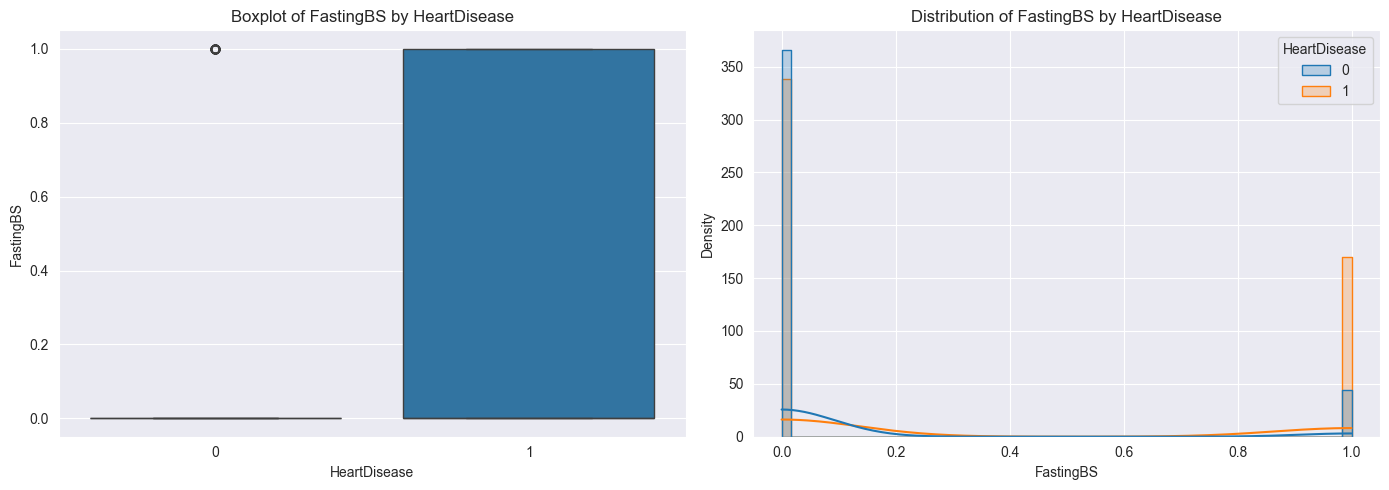

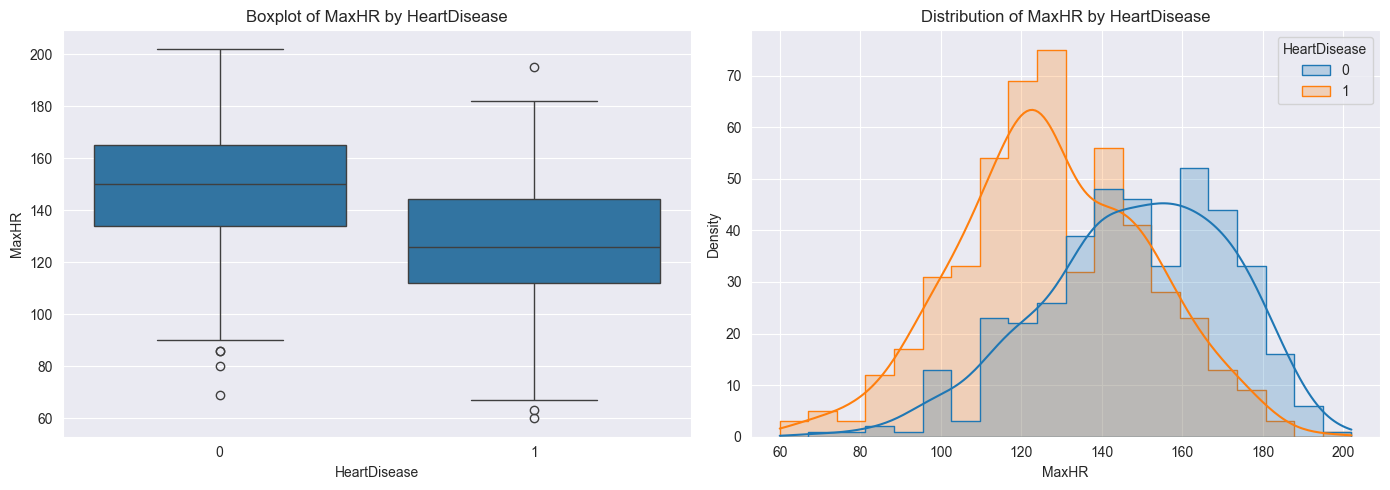

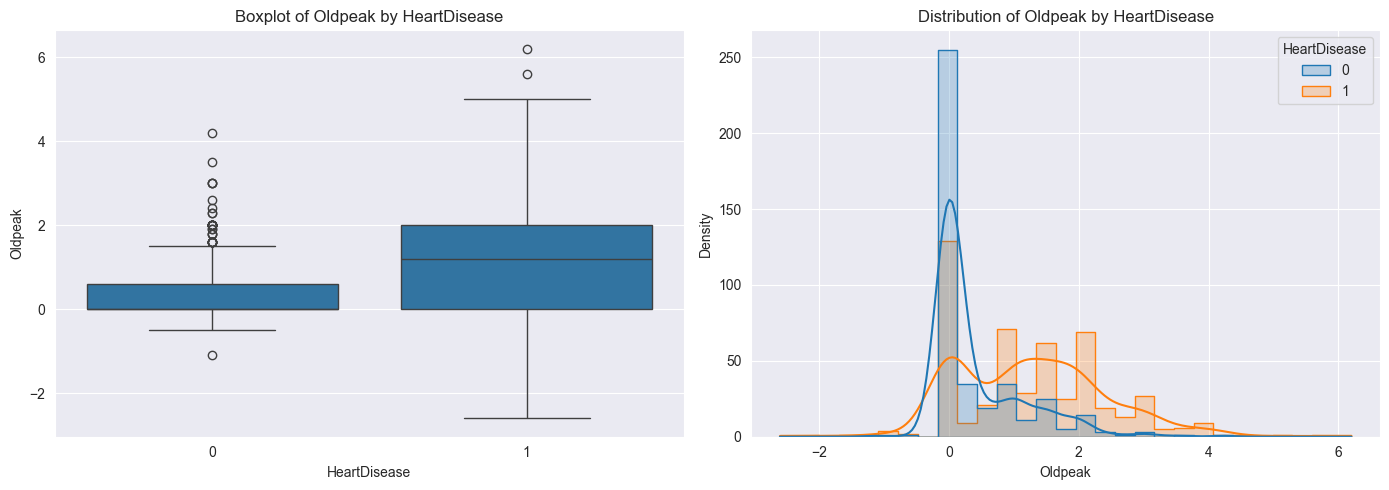

In [265]:
target = "HeartDisease"

# Automatically detect numerical columns (excluding target)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != target]

print("Numerical columns:", num_cols)

# ---- LOOP ----
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- 1️⃣ Boxplot ---
    sns.boxplot(x=target, y=col, data=df, ax=axes[0])
    axes[0].set_title(f"Boxplot of {col} by {target}")
    axes[0].set_xlabel(target)
    axes[0].set_ylabel(col)

    # --- 2️⃣ KDE/Histogram ---
    sns.histplot(data=df, x=col, hue=target, kde=True, ax=axes[1], element='step')
    axes[1].set_title(f"Distribution of {col} by {target}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()


The abouve bivariate analysis shows the relationship of each column with the target column i.e. HeartDisease column.

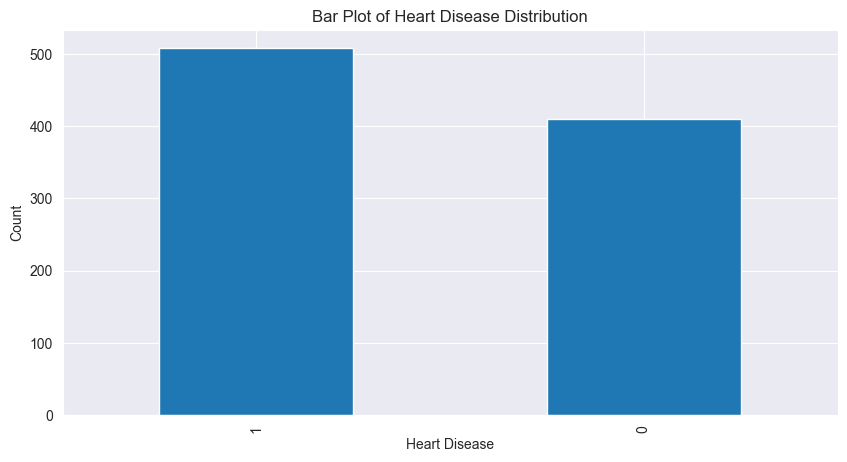

In [266]:
plt.figure(figsize=(10,5))
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title("Bar Plot of Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

Both the classes 0 and 1 are in almost equal proportion so we can apply Logistic regression here.

## Preparing the data for fitting the model

In [267]:
# Split first
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Column detection from training data
cat_cols = x_train.select_dtypes(include=['object', 'category']).columns
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

# Pipeline
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=10,
    ))
])


# Model Fitting

In [268]:
# Train the model
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

# Prediction

In [269]:
print(x_train.shape)
print(x_test.shape)


(734, 11)
(184, 11)


In [270]:
prediction = pipeline.predict(x_test)

# Model Evaluation

In [271]:
cfn = confusion_matrix(y_test, prediction)
print(cfn)

[[72 10]
 [10 92]]


In [272]:
acc = accuracy_score(y_test, prediction)
prec = precision_score(y_test, prediction)
rec = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


Accuracy: 0.8913043478260869
Precision: 0.9019607843137255
Recall: 0.9019607843137255
F1 Score: 0.9019607843137255


## Evaluation on training data

In [273]:
prediction1 = pipeline.predict(x_train)
cfn1 = confusion_matrix(y_train, prediction1)
print(cfn1)
acc1 = accuracy_score(y_train, prediction1)
prec1 = precision_score(y_train, prediction1)
rec1 = recall_score(y_train, prediction1)
f11 = f1_score(y_train, prediction1)

print("Accuracy:", acc1)
print("Precision:", prec1)
print("Recall:", rec1)
print("F1 Score:", f11)

[[320   8]
 [  4 402]]
Accuracy: 0.9836512261580381
Precision: 0.9804878048780488
Recall: 0.9901477832512315
F1 Score: 0.9852941176470589


In [274]:
import pickle

# Save the trained Logistic Regression model
with open("model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [275]:
import pickle

with open("model.pkl", "rb") as file:
    model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [276]:
# --- Your actual preprocessor is "trans", not preprocessor ---
# --- Your categorical transformer name is "tnf1" ---

# Extract categorical feature names from OneHotEncoder
cat_feature_names = trans.named_transformers_['tnf1'].get_feature_names_out(cat_cols)

# Numeric feature names
num_feature_names = num_cols.tolist()

# Final model feature order
model_columns = num_feature_names + list(cat_feature_names)

# ---- Save model (lr), preprocessor (trans), and model_columns ----

# Save trained model
with open("model.pkl", "wb") as file:
    pickle.dump(lr, file)

# Save preprocessor (OHE + Scaler inside ColumnTransformer)
with open("preprocessor.pkl", "wb") as file:
    pickle.dump(trans, file)

# Save model column names
with open("model_columns.pkl", "wb") as file:
    pickle.dump(model_columns, file)

print("All files saved: model.pkl, preprocessor.pkl, model_columns.pkl")

All files saved: model.pkl, preprocessor.pkl, model_columns.pkl


In [277]:
# Load trained model
model = pickle.load(open("model.pkl", "rb"))

# Load preprocessor
preprocessor = pickle.load(open("preprocessor.pkl", "rb"))

# Load the model column list
model_columns = pickle.load(open("model_columns.pkl", "rb"))

print("Everything loaded successfully!")

Everything loaded successfully!


In [278]:
def predict(Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS,
            RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope):

    # Input ko DataFrame me convert
    input_df = pd.DataFrame([{
        "Age": Age,
        "Sex": Sex,
        "ChestPainType": ChestPainType,
        "RestingBP": RestingBP,
        "Cholesterol": Cholesterol,
        "FastingBS": FastingBS,
        "RestingECG": RestingECG,
        "MaxHR": MaxHR,
        "ExerciseAngina": ExerciseAngina,
        "Oldpeak": Oldpeak,
        "ST_Slope": ST_Slope
    }])

    # Apply the preprocessor to the input data
    # This handles both one-hot encoding for categorical and standard scaling for numerical features
    processed_input = preprocessor.transform(input_df)

    # Predict
    prediction = model.predict(processed_input)[0]

    return "Heart Disease Likely" if prediction == 1 else "No Heart Disease"

In [279]:
import gradio as gr

iface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(["M", "F"], label="Sex"),
        gr.Dropdown(["TA", "ATA", "NAP", "ASY"], label="Chest Pain Type"),
        gr.Number(label="Resting BP"),
        gr.Number(label="Cholesterol"),
        gr.Number(label="Fasting BS (0 or 1)"),
        gr.Dropdown(["Normal", "ST", "LVH"], label="Resting ECG"),
        gr.Number(label="Max HR"),
        gr.Dropdown(["Y", "N"], label="Exercise Angina"),
        gr.Number(label="Oldpeak"),
        gr.Dropdown(["Up", "Flat", "Down"], label="ST Slope")
    ],
    outputs="text",
    title="Heart Disease Prediction Model",
    description="Enter patient details to get prediction"
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://7511445f920b7da3b7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Future Enhancement

In the future we plan to add more parameters and more number of columns in outr dataset. We also plan to contact local hospitals and request patient data to build a similar model for them.